In [229]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))

battery_path = "../data/raw"

files = sorted(os.listdir(battery_path))

len(files)

7565

In [230]:
sample_df = pd.read_csv(os.path.join(battery_path, files[0]))
sample_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


In [231]:
def compute_capacity(df):
    time = df["Time"].values
    current = df["Current_load"].values
    
    dt = np.diff(time)
    current = current[:-1]
    
    capacity = np.sum(current * dt) / 3600  # перевод в Ah
    return abs(capacity)

In [232]:
sample_df = pd.read_csv(os.path.join(battery_path, files[0]))
print(sample_df.columns)
print(sample_df["Time"].max())

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_load', 'Voltage_load', 'Time'],
      dtype='object')
6436.141


In [233]:
capacities = []

for f in files:
    df = pd.read_csv(os.path.join(battery_path, f))
    cap = compute_capacity(sample_df)
    capacities.append(cap)

capacities = np.array(capacities)

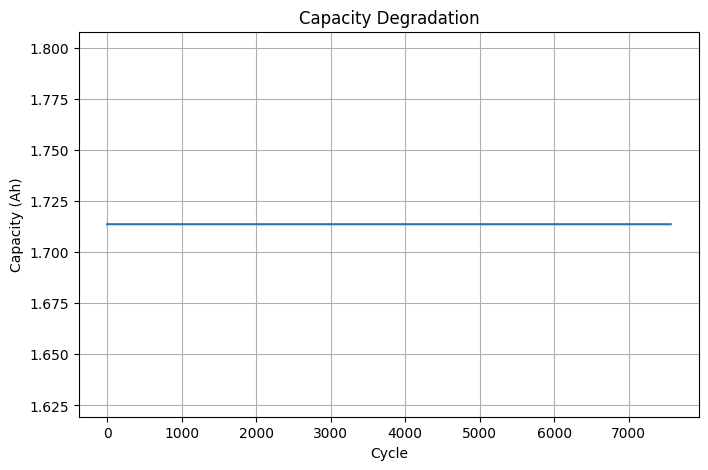

In [234]:
plt.figure(figsize=(8,5))
plt.plot(capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation")
plt.grid(True)
plt.show()

In [235]:
print(sample_df["Current_load"].min(), sample_df["Current_load"].max())

0.0002 1.0


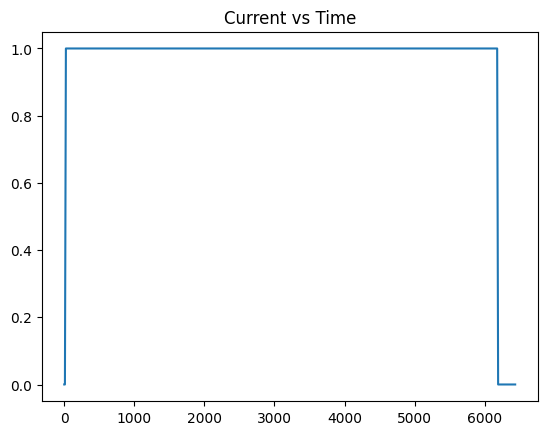

In [236]:
plt.plot(sample_df["Time"], sample_df["Current_load"])
plt.title("Current vs Time")
plt.show()

In [237]:
capacities = []

for f in files:
    df = pd.read_csv(os.path.join(battery_path, f))
    cap = compute_capacity(sample_df)
    capacities.append(cap)

capacities = np.array(capacities)

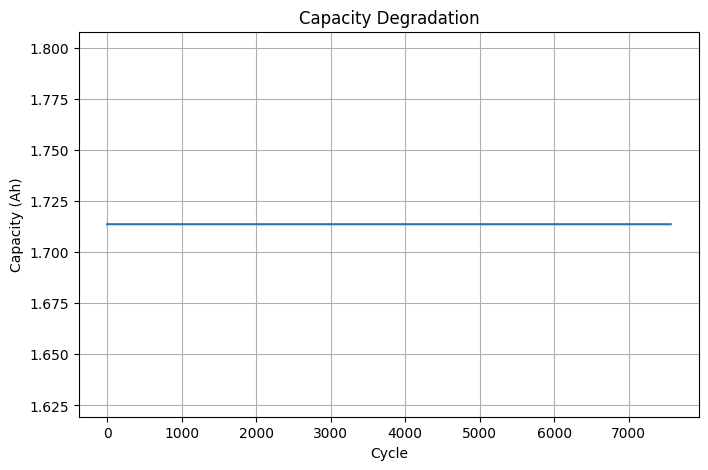

In [238]:
plt.figure(figsize=(8,5))
plt.plot(capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation")
plt.grid(True)
plt.show()

In [239]:
def compute_capacity(df):
    df.columns = df.columns.str.strip()

    discharge = df[df["Current_measured"] < 0]

    time = discharge["Time"].values
    current = discharge["Current_measured"].values

    dt = np.diff(time)
    current = current[:-1]

    capacity = np

In [240]:
capacities = []

for f in files:
    df = pd.read_csv(os.path.join(battery_path, f))
    cap = compute_capacity(sample_df)
    capacities.append(cap)

capacities = np.array(capacities)

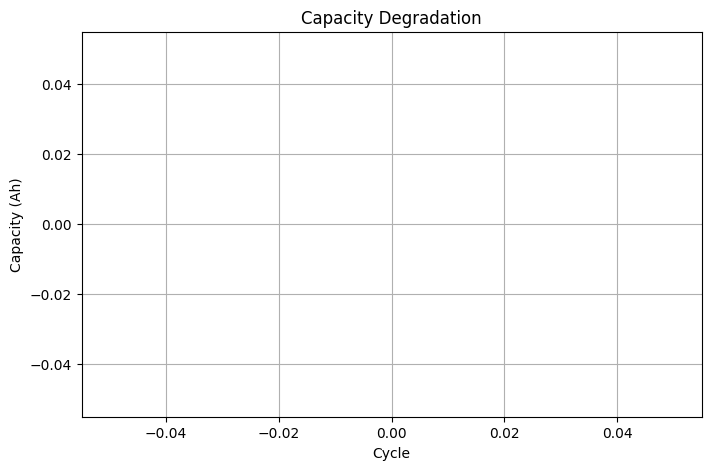

In [241]:
plt.figure(figsize=(8,5))
plt.plot(capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation")
plt.grid(True)
plt.show()

In [242]:
df = pd.read_csv(os.path.join(battery_path, files[0]))
df.columns = df.columns.str.strip()

print("Current_measured:", df["Current_measured"].min(), df["Current_measured"].max())
print("Current_load:", df["Current_load"].min(), df["Current_load"].max())

Current_measured: -1.00110134824347 0.000252388610586
Current_load: 0.0002 1.0


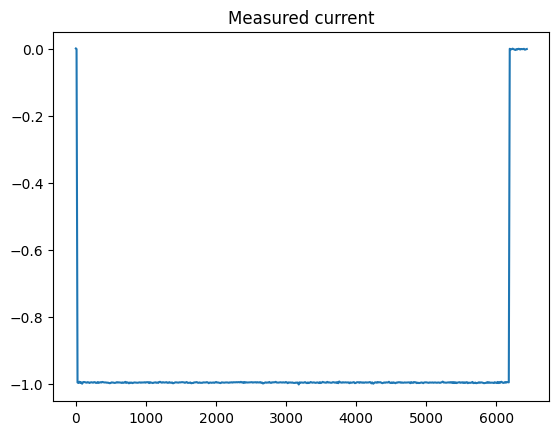

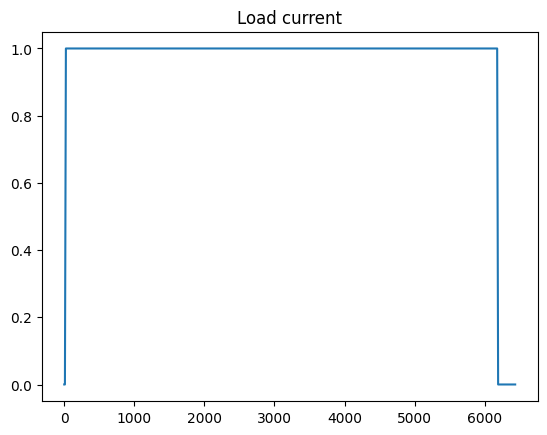

In [243]:
plt.plot(df["Time"], df["Current_measured"])
plt.title("Measured current")
plt.show()

plt.plot(df["Time"], df["Current_load"])
plt.title("Load current")
plt.show()

In [244]:
def compute_capacity(df):
    df.columns = df.columns.str.strip()

    time = df["Time"].values
    current = df["Current_measured"].values

    dt = np.diff(time)
    current = current[:-1]

    capacity = np.sum(current * dt) / 3600
    return capacity

In [245]:
def compute_capacity(df):
    df.columns = df.columns.str.strip()

    time = df["Time"].values
    current = df["Current_measured"].values  # уже отрицательный

    dt = np.diff(time)
    current = current[:-1]

    capacity = -np.sum(current * dt) / 3600  # минус убираем знак
    return capacity

In [246]:
print(compute_capacity(pd.read_csv(os.path.join(battery_path, files[0]))))

1.7058795455094353


In [247]:
def compute_capacity(df):
    df.columns = df.columns.str.strip()

    time = df["Time"].values
    current = df["Current_measured"].values

    if len(time) < 2:
        return np.nan

    dt = np.diff(time)
    current = current[:-1]

    capacity = -np.sum(current * dt) / 3600
    return capacity

In [248]:
capacities = []

for f in files:
    df = pd.read_csv(os.path.join(battery_path, f))
    cap = compute_capacity(sample_df)
    capacities.append(cap)

capacities = np.array(capacities, dtype=float)

In [249]:
print(capacities[:20])
print("min:", np.nanmin(capacities))
print("max:", np.nanmax(capacities))
print("std:", np.nanstd(capacities))

[1.70587955 1.70587955 1.70587955 1.70587955 1.70587955 1.70587955
 1.70587955 1.70587955 1.70587955 1.70587955 1.70587955 1.70587955
 1.70587955 1.70587955 1.70587955 1.70587955 1.70587955 1.70587955
 1.70587955 1.70587955]
min: 1.7058795455094353
max: 1.7058795455094353
std: 6.661338147750939e-16


In [250]:
df = pd.read_csv(os.path.join(battery_path, files[0]))
print(list(df.columns))

['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']


In [251]:
df.columns = df.columns.str.strip().str.lower()
print(list(df.columns))

['voltage_measured', 'current_measured', 'temperature_measured', 'current_load', 'voltage_load', 'time']


In [252]:
for col in df.columns:
    print(f"'{col}'")

'voltage_measured'
'current_measured'
'temperature_measured'
'current_load'
'voltage_load'
'time'


In [253]:
import pandas as pd
import os

battery_path = "../data/raw"
files = sorted(os.listdir(battery_path))

df = pd.read_csv(os.path.join(battery_path, files[0]), encoding="utf-8-sig")

print("RAW COLUMNS:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

RAW COLUMNS:
0 'Voltage_measured'
1 'Current_measured'
2 'Temperature_measured'
3 'Current_load'
4 'Voltage_load'
5 'Time'


In [254]:
print(df.columns.tolist())

['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']


In [255]:
voltage_col = [c for c in df.columns if "voltage" in c.lower()][0]
current_col = [c for c in df.columns if "current" in c.lower()][0]
time_col = [c for c in df.columns if "time" in c.lower()][0]

In [256]:
print(files)

['00001.csv', '00002.csv', '00003.csv', '00004.csv', '00005.csv', '00006.csv', '00007.csv', '00008.csv', '00009.csv', '00010.csv', '00011.csv', '00012.csv', '00013.csv', '00014.csv', '00015.csv', '00016.csv', '00017.csv', '00018.csv', '00019.csv', '00020.csv', '00021.csv', '00022.csv', '00023.csv', '00024.csv', '00025.csv', '00026.csv', '00027.csv', '00028.csv', '00029.csv', '00030.csv', '00031.csv', '00032.csv', '00033.csv', '00034.csv', '00035.csv', '00036.csv', '00037.csv', '00038.csv', '00039.csv', '00040.csv', '00041.csv', '00042.csv', '00043.csv', '00044.csv', '00045.csv', '00046.csv', '00047.csv', '00048.csv', '00049.csv', '00050.csv', '00051.csv', '00052.csv', '00053.csv', '00054.csv', '00055.csv', '00056.csv', '00057.csv', '00058.csv', '00059.csv', '00060.csv', '00061.csv', '00062.csv', '00063.csv', '00064.csv', '00065.csv', '00066.csv', '00067.csv', '00068.csv', '00069.csv', '00070.csv', '00071.csv', '00072.csv', '00073.csv', '00074.csv', '00075.csv', '00076.csv', '00077.csv'

In [257]:
discharge_files = []
impedance_files = []

for f in files:
    path = os.path.join(battery_path, f)
    df_temp = pd.read_csv(path, nrows=0)  # read only header, fast
    cols = df_temp.columns.str.strip().str.lower().tolist()
    if "voltage_measured" in cols:
        discharge_files.append(f)
    elif "battery_impedance" in cols:
        impedance_files.append(f)

print(f"Discharge files: {len(discharge_files)}")
print(f"Impedance files: {len(impedance_files)}")

Discharge files: 5609
Impedance files: 1956


In [258]:
df1 = pd.read_csv(os.path.join(battery_path, discharge_files[0]))
df2 = pd.read_csv(os.path.join(battery_path, discharge_files[1]))

df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()

min_len = min(len(df1), len(df2))
print("Voltage equal:", np.allclose(df1["voltage_measured"][:min_len], df2["voltage_measured"][:min_len]))
print("Current equal:", np.allclose(df1["current_measured"][:min_len], df2["current_measured"][:min_len]))
print("Time equal:",    np.allclose(df1["time"][:min_len],             df2["time"][:min_len]))

Voltage equal: False
Current equal: False
Time equal: False


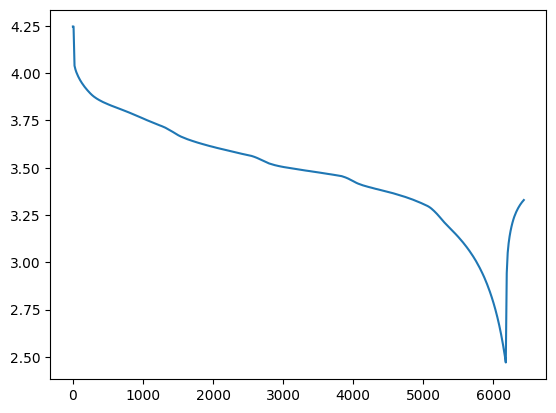

2.470611866932728 4.246764125510136


In [259]:
plt.plot(df1["time"], df1["voltage_measured"])
plt.show()

print(df1["voltage_measured"].min(), df1["voltage_measured"].max())

In [260]:
all_data = []

for f in discharge_files:
    df = pd.read_csv(os.path.join(battery_path, f))
    df.columns = df.columns.str.strip().str.lower()
    all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

print(len(full_df))

7282946


In [261]:
full_df["new_cycle"] = full_df["voltage_measured"].diff() > 1.0
cycle_indices = full_df.index[full_df["new_cycle"]]

In [262]:
all_data = []

for f in files:
    df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
    df.columns = df.columns.str.strip().str.lower()
    all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

print(full_df.shape)

(7376834, 13)


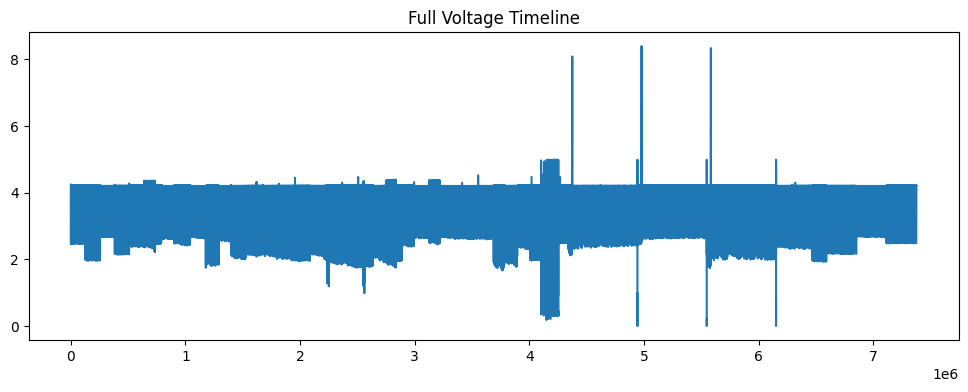

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(full_df["voltage_measured"].values)
plt.title("Full Voltage Timeline")
plt.show()

In [264]:
full_df["voltage_diff"] = full_df["voltage_measured"].diff()

# большой скачок вверх = начало нового цикла
cycle_starts = full_df.index[full_df["voltage_diff"] > 1.0]

len(cycle_starts)

1047

In [265]:
high_voltage = full_df["voltage_measured"] > 4.15

cycle_starts = full_df.index[
    (high_voltage) &
    (full_df["voltage_measured"].shift(1) < 4.15)
]

len(cycle_starts)

3089

In [266]:
import numpy as np

full_df["current_sign"] = np.sign(full_df["current_measured"])

cycle_starts = full_df.index[
    (full_df["current_sign"] > 0) &
    (full_df["current_sign"].shift(1) < 0)
]

len(cycle_starts)

74989

In [267]:
cycle_starts = cycle_starts[
    np.diff(np.insert(cycle_starts, 0, 0)) > 1000
]

In [268]:
print(full_df["time"].min(), full_df["time"].max())

0.0 10818.797


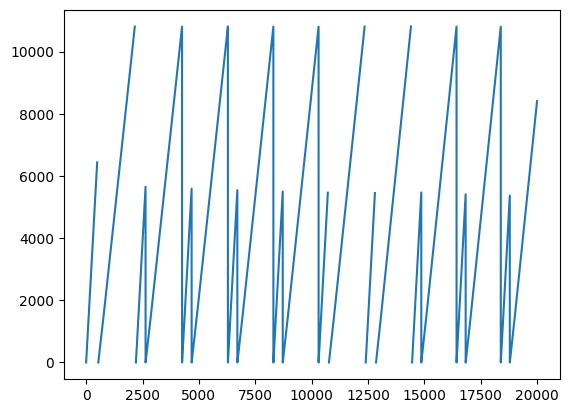

In [269]:
plt.plot(full_df["time"].values[:20000])
plt.show()

In [270]:
print(files[:20])

['00001.csv', '00002.csv', '00003.csv', '00004.csv', '00005.csv', '00006.csv', '00007.csv', '00008.csv', '00009.csv', '00010.csv', '00011.csv', '00012.csv', '00013.csv', '00014.csv', '00015.csv', '00016.csv', '00017.csv', '00018.csv', '00019.csv', '00020.csv']


In [271]:
df.head()

,voltage_measured,current_measured,temperature_measured,current_charge,voltage_charge,time
0,3.742571,0.001106,11.838381,-0.0006,0.002,0.000
1,3.925105,1.491764,11.780438,1.4995,4.808,2.579
2,3.940043,1.491915,11.652214,1.4995,4.821,8.610
3,3.949894,1.491505,11.570002,1.4995,4.834,14.547
4,3.957889,1.492496,11.472317,1.4995,4.834,20.500


In [272]:
def compute_capacity(df):
    df.columns = df.columns.str.strip().str.lower()

    discharge = df[df["current_measured"] < 0]

    time = discharge["time"].values
    current = discharge["current_measured"].values

    if len(time) < 2:
        return np.nan

    dt = np.diff(time)
    current = current[:-1]

    capacity = -np.sum(current * dt) / 3600
    return capacity

In [273]:
def compute_capacity(df):
    df.columns = df.columns.str.strip().str.lower()

    discharge = df[df["current_measured"] < 0]

    if len(discharge) < 2:
        return np.nan

    time = discharge["time"].values
    current = discharge["current_measured"].values

    dt = np.diff(time)
    current = current[:-1]

    capacity = -np.sum(current * dt) / 3600
    return capacity

In [274]:
capacities = []

for f in files:
    try:
        df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
        cap = compute_capacity(df)
        capacities.append(cap)
    except Exception as e:
        print("ERROR in file:", f)
        print(e)
        capacities.append(np.nan)

capacities = np.array(capacities)

ERROR in file: 00002.csv
'current_measured'
ERROR in file: 00004.csv
'current_measured'
ERROR in file: 00014.csv
'current_measured'
ERROR in file: 00016.csv
'current_measured'
ERROR in file: 00018.csv
'current_measured'
ERROR in file: 00020.csv
'current_measured'
ERROR in file: 00030.csv
'current_measured'
ERROR in file: 00032.csv
'current_measured'
ERROR in file: 00034.csv
'current_measured'
ERROR in file: 00036.csv
'current_measured'
ERROR in file: 00046.csv
'current_measured'
ERROR in file: 00048.csv
'current_measured'
ERROR in file: 00058.csv
'current_measured'
ERROR in file: 00060.csv
'current_measured'
ERROR in file: 00070.csv
'current_measured'
ERROR in file: 00072.csv
'current_measured'
ERROR in file: 00082.csv
'current_measured'
ERROR in file: 00084.csv
'current_measured'
ERROR in file: 00086.csv
'current_measured'
ERROR in file: 00088.csv
'current_measured'
ERROR in file: 00098.csv
'current_measured'
ERROR in file: 00100.csv
'current_measured'
ERROR in file: 00110.csv
'curren

In [275]:
def compute_capacity(df):
    print("COLUMNS:", list(df.columns))
    return 0

In [276]:
def compute_capacity(df):
    # чистим колонки
    df.columns = df.columns.str.strip().str.lower()

    print("USING COLUMNS:", df.columns.tolist())

    # автоматически ищем нужные колонки
    time_col = [c for c in df.columns if "time" in c][0]
    current_col = [c for c in df.columns if "current_measured" in c][0]

    discharge = df[df[current_col] < 0]

    if len(discharge) < 2:
        return np.nan

    time = discharge[time_col].values
    current = discharge[current_col].values

    dt = np.diff(time)
    current = current[:-1]

    capacity = -np.sum(current * dt) / 3600
    return capacity

In [277]:
def compute_capacity(df):
    # нормализуем колонки
    df.columns = df.columns.str.strip().str.lower()
    
    # проверка
    required_cols = ["current_measured", "time"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    # берём только discharge
    discharge = df[df["current_measured"] < 0]

    if len(discharge) < 2:
        return np.nan

    time = discharge["time"].values
    current = discharge["current_measured"].values

    dt = np.diff(time)
    current = current[:-1]

    capacity = -np.sum(current * dt) / 3600
    return capacity

In [278]:
capacities = []

for f in discharge_files:
    df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
    df.columns = df.columns.str.strip().str.lower()  # normalize column names
    cap = compute_capacity(df)
    capacities.append(cap)

capacities = np.array(capacities, dtype=float)

In [279]:
print("min:", np.nanmin(capacities))
print("max:", np.nanmax(capacities))
print("std:", np.nanstd(capacities))

min: 9.101250777007731e-09
max: 11.299584848787775
std: 3.184027163415302


In [280]:
idx_max = np.nanargmax(capacities)
print("File with max capacity:", files[idx_max])

df = pd.read_csv(os.path.join(battery_path, files[idx_max]))
df.columns = df.columns.str.strip().str.lower()

discharge = df[df["current_measured"] < 0]

print("Discharge rows:", len(discharge))
print("Time range:", discharge["time"].min(), discharge["time"].max())
print("Current range:", discharge["current_measured"].min(), discharge["current_measured"].max())

File with max capacity: 04245.csv
Discharge rows: 145
Time range: 0.0 1573.734
Current range: -3.978371819312698 -0.0001383187875609


In [281]:
t = discharge["time"].values
print("Monotonic increasing?", np.all(np.diff(t) >= 0))

Monotonic increasing? True


In [282]:
discharge = discharge.sort_values("time")

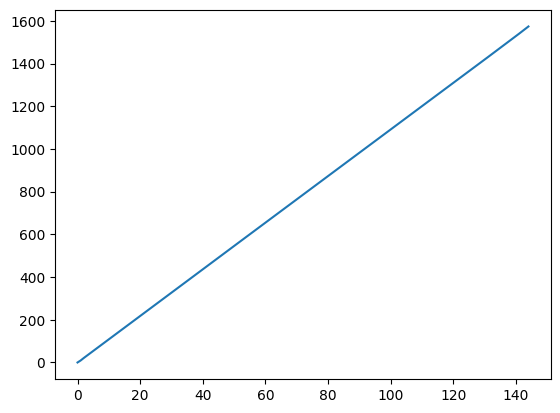

In [283]:
plt.plot(discharge["time"])
plt.show()

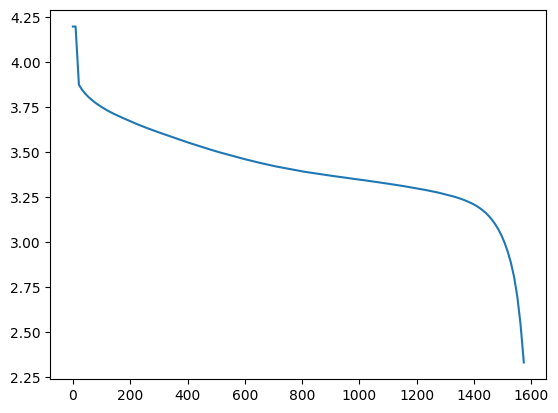

In [284]:
plt.plot(discharge["time"], discharge["voltage_measured"])
plt.show()

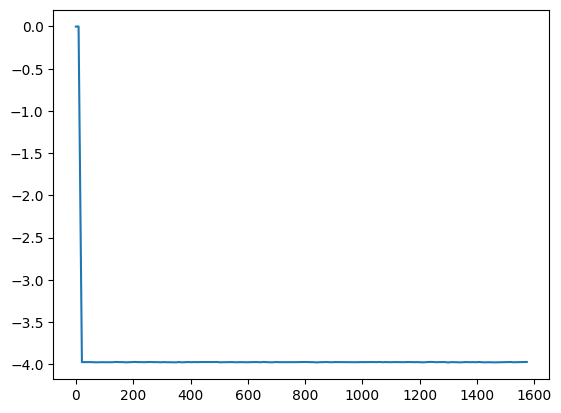

Mean current: -3.919678832661814


In [285]:
plt.plot(discharge["time"], discharge["current_measured"])
plt.show()

print("Mean current:", discharge["current_measured"].mean())

In [286]:
def compute_capacity(df):
    df.columns = df.columns.str.strip().str.lower()

    discharge = df[df["current_measured"] < 0]

    if len(discharge) < 2:
        return np.nan

    time = discharge["time"].values
    current = discharge["current_measured"].values

    dt = np.diff(time)

    # убираем отрицательные скачки времени
    valid = dt > 0
    dt = dt[valid]
    current = current[:-1][valid]

    capacity = -np.sum(current * dt) / 60
    return capacity

In [287]:
print("min:", np.nanmin(capacities))
print("max:", np.nanmax(capacities))
print("std:", np.nanstd(capacities))

min: 9.101250777007731e-09
max: 11.299584848787775
std: 3.184027163415302


In [288]:
idx_max = np.nanargmax(capacities)
print("Max file:", files[idx_max])

df = pd.read_csv(os.path.join(battery_path, files[idx_max]))
df.columns = df.columns.str.strip().str.lower()

discharge = df[df["current_measured"] < 0]

print("Rows:", len(discharge))
print("Time range:", discharge["time"].min(), discharge["time"].max())
print("Mean current:", discharge["current_measured"].mean())

Max file: 04245.csv
Rows: 145
Time range: 0.0 1573.734
Mean current: -3.919678832661814


In [289]:
print("First 10 time values:")
print(discharge["time"].values[:10])

First 10 time values:
[ 0.     9.344 21.031 31.937 42.859 53.734 64.641 75.531 86.422 97.422]


In [290]:
print("min:", np.nanmin(capacities))
print("max:", np.nanmax(capacities))
print("std:", np.nanstd(capacities))

min: 9.101250777007731e-09
max: 11.299584848787775
std: 3.184027163415302


In [291]:
def compute_capacity(df):
    df.columns = df.columns.str.strip().str.lower()

    discharge = df[df["current_measured"] < 0]

    if len(discharge) < 2:
        return np.nan

    time = discharge["time"].values
    current = discharge["current_measured"].values

    dt = np.diff(time)

    # убираем отрицательные скачки времени
    valid = dt > 0
    dt = dt[valid]
    current = current[:-1][valid]

    capacity = -np.sum(current * dt) / 60
    return capacity

In [292]:
print("min:", np.nanmin(capacities))
print("max:", np.nanmax(capacities))
print("std:", np.nanstd(capacities))

min: 9.101250777007731e-09
max: 11.299584848787775
std: 3.184027163415302


In [293]:
df = pd.read_csv(os.path.join(battery_path, files[0]))
df.columns = df.columns.str.strip().str.lower()

discharge = df[df["current_measured"] < 0]

time = discharge["time"].values
current = discharge["current_measured"].values

dt = np.diff(time)
current_trim = current[:-1]

print("Mean current:", current.mean())
print("Time max:", time.max())

raw_integral = -np.sum(current_trim * dt)
print("Raw integral:", raw_integral)
print("Capacity Ah:", raw_integral / 3600)

Mean current: -0.9547157548863174
Time max: 6436.141
Raw integral: 6141.168726191363
Capacity Ah: 1.7058802017198231


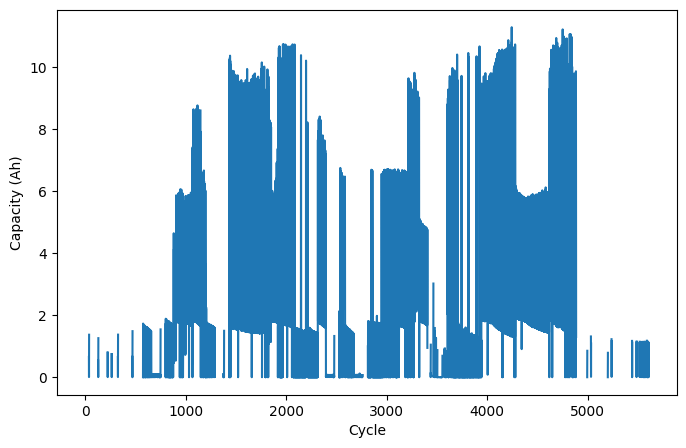

In [294]:
plt.figure(figsize=(8,5))
plt.plot(capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.show()

In [295]:
print(capacities[:20])
print(capacities[-20:])

[1.7058802         nan 1.5484803         nan 1.5322682         nan
 1.51156251        nan 1.49517405        nan 1.47695527        nan
 1.47403916        nan 1.46310556        nan 1.44374917        nan
 1.42830392        nan]
[1.17794581e+00            nan 1.10434214e+00            nan
 1.07327891e+00 2.55319058e-05 1.05386774e+00 4.66454670e-03
 1.14686624e+00            nan 1.09497292e+00 2.67174173e-05
 1.09070147e+00            nan 1.12189139e+00            nan
 1.10886726e+00 2.78522193e-03 1.10780402e+00            nan]


In [296]:
valid_mask = ~np.isnan(capacities) & (capacities > 0.5)
clean_capacities = capacities[valid_mask]

print("Original count:", len(capacities))
print("Valid count:", len(clean_capacities))

Original count: 5609
Valid count: 3774


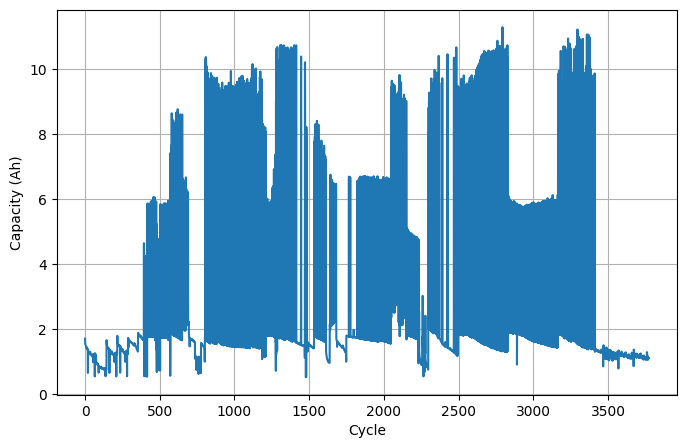

In [297]:
plt.figure(figsize=(8,5))
plt.plot(clean_capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.grid(True)
plt.show()

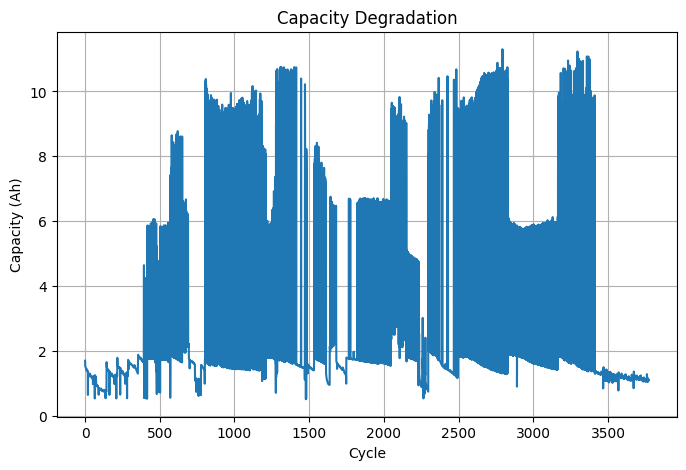

In [298]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(clean_capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation")
plt.grid(True)
plt.show()

In [299]:
valid_mask = (capacities > 0.5) & (capacities < 3.0)
clean_capacities = capacities[valid_mask]

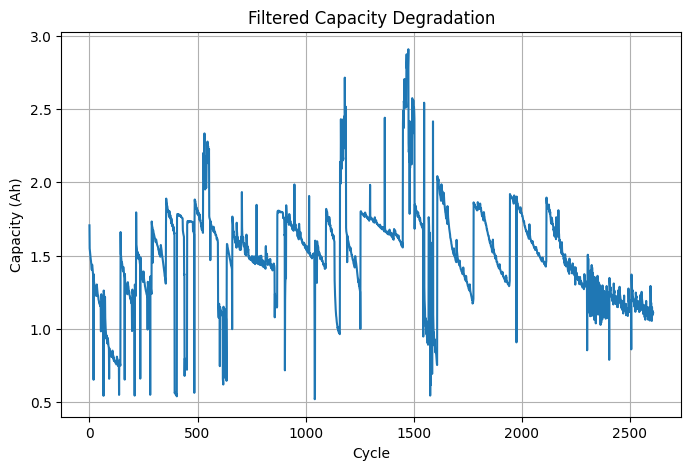

In [300]:
plt.figure(figsize=(8,5))
plt.plot(clean_capacities)
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Filtered Capacity Degradation")
plt.grid(True)
plt.show()

In [301]:
mean_currents = []

for f in files:
    try:
        df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
        df.columns = df.columns.str.strip().str.lower()

        if "current_measured" not in df.columns:
            mean_currents.append(np.nan)
            continue

        discharge = df[df["current_measured"] < 0]

        if len(discharge) > 10:
            mean_currents.append(discharge["current_measured"].mean())
        else:
            mean_currents.append(np.nan)

    except Exception as e:
        print("Problem in file:", f)
        print(e)
        mean_currents.append(np.nan)

mean_currents = np.array(mean_currents)

In [302]:
valid_currents = mean_currents[~np.isnan(mean_currents)]
print(np.unique(np.round(valid_currents, 2)))

[-4.02 -4.   -3.99 -3.98 -3.97 -3.95 -3.94 -3.93 -3.92 -3.91 -3.9  -3.89
 -3.88 -3.87 -3.86 -3.85 -3.84 -3.83 -3.82 -3.81 -3.8  -3.79 -3.78 -3.77
 -3.76 -3.75 -3.74 -3.72 -3.66 -3.32 -3.3  -3.   -2.99 -2.96 -2.93 -2.92
 -2.89 -2.88 -2.74 -2.57 -2.22 -2.2  -2.19 -2.17 -2.16 -2.15 -2.12 -2.11
 -2.1  -2.09 -2.04 -2.03 -2.01 -2.   -1.99 -1.98 -1.97 -1.96 -1.95 -1.94
 -1.93 -1.92 -1.91 -1.9  -1.89 -1.88 -1.87 -1.86 -1.85 -1.84 -1.83 -1.82
 -1.81 -1.8  -1.79 -1.78 -1.77 -1.76 -1.75 -1.74 -1.73 -1.72 -1.71 -1.7
 -1.69 -1.68 -1.67 -1.66 -1.65 -1.64 -1.63 -1.62 -1.61 -1.6  -1.59 -1.58
 -1.57 -1.56 -1.55 -1.54 -1.53 -1.52 -1.51 -1.5  -1.49 -1.48 -1.46 -1.45
 -1.44 -1.43 -1.42 -1.4  -1.39 -1.38 -1.37 -1.36 -1.35 -1.34 -1.33 -1.32
 -1.31 -1.3  -1.29 -1.28 -1.27 -1.26 -1.24 -1.23 -1.22 -1.2  -1.19 -1.18
 -1.17 -1.16 -1.15 -1.14 -1.13 -1.12 -1.11 -1.1  -1.09 -1.07 -1.06 -1.05
 -1.01 -1.   -0.99 -0.98 -0.97 -0.96 -0.95 -0.94 -0.93 -0.92 -0.91 -0.9
 -0.86 -0.84 -0.83 -0.81 -0.8  -0.78 -0.77 -0.76 -0.7

In [303]:
valid_currents = mean_currents[~np.isnan(mean_currents)]
print(np.unique(np.round(valid_currents, 2)))

[-4.02 -4.   -3.99 -3.98 -3.97 -3.95 -3.94 -3.93 -3.92 -3.91 -3.9  -3.89
 -3.88 -3.87 -3.86 -3.85 -3.84 -3.83 -3.82 -3.81 -3.8  -3.79 -3.78 -3.77
 -3.76 -3.75 -3.74 -3.72 -3.66 -3.32 -3.3  -3.   -2.99 -2.96 -2.93 -2.92
 -2.89 -2.88 -2.74 -2.57 -2.22 -2.2  -2.19 -2.17 -2.16 -2.15 -2.12 -2.11
 -2.1  -2.09 -2.04 -2.03 -2.01 -2.   -1.99 -1.98 -1.97 -1.96 -1.95 -1.94
 -1.93 -1.92 -1.91 -1.9  -1.89 -1.88 -1.87 -1.86 -1.85 -1.84 -1.83 -1.82
 -1.81 -1.8  -1.79 -1.78 -1.77 -1.76 -1.75 -1.74 -1.73 -1.72 -1.71 -1.7
 -1.69 -1.68 -1.67 -1.66 -1.65 -1.64 -1.63 -1.62 -1.61 -1.6  -1.59 -1.58
 -1.57 -1.56 -1.55 -1.54 -1.53 -1.52 -1.51 -1.5  -1.49 -1.48 -1.46 -1.45
 -1.44 -1.43 -1.42 -1.4  -1.39 -1.38 -1.37 -1.36 -1.35 -1.34 -1.33 -1.32
 -1.31 -1.3  -1.29 -1.28 -1.27 -1.26 -1.24 -1.23 -1.22 -1.2  -1.19 -1.18
 -1.17 -1.16 -1.15 -1.14 -1.13 -1.12 -1.11 -1.1  -1.09 -1.07 -1.06 -1.05
 -1.01 -1.   -0.99 -0.98 -0.97 -0.96 -0.95 -0.94 -0.93 -0.92 -0.91 -0.9
 -0.86 -0.84 -0.83 -0.81 -0.8  -0.78 -0.77 -0.76 -0.7

In [304]:
capacities = []
mean_currents = []

for f in files:
    try:
        df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
        df.columns = df.columns.str.strip().str.lower()

        if "current_measured" not in df.columns:
            capacities.append(np.nan)
            mean_currents.append(np.nan)
            continue

        discharge = df[df["current_measured"] < 0]

        if len(discharge) < 10:
            capacities.append(np.nan)
            mean_currents.append(np.nan)
            continue

        # capacity
        time = discharge["time"].values
        current = discharge["current_measured"].values
        dt = np.diff(time)
        current_trim = current[:-1]

        cap = -np.sum(current_trim * dt) / 3600

        capacities.append(cap)
        mean_currents.append(discharge["current_measured"].mean())

    except:
        capacities.append(np.nan)
        mean_currents.append(np.nan)

capacities = np.array(capacities)
mean_currents = np.array(mean_currents)

print(len(capacities), len(mean_currents))

7565 7565


In [305]:
main_mask = np.abs(mean_currents + 1.0) < 0.1
main_capacities = capacities[main_mask]

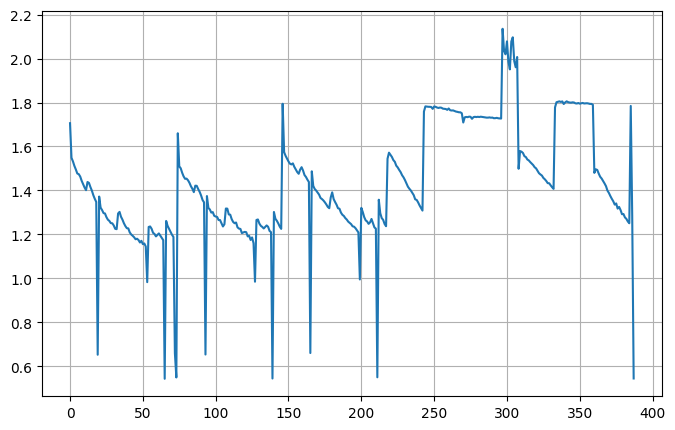

In [306]:
plt.figure(figsize=(8,5))
plt.plot(main_capacities)
plt.grid(True)
plt.show()

In [307]:
durations = []

for f in files:
    try:
        df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
        df.columns = df.columns.str.strip().str.lower()

        if "current_measured" not in df.columns:
            durations.append(np.nan)
            continue

        discharge = df[df["current_measured"] < 0]

        if len(discharge) < 10:
            durations.append(np.nan)
            continue

        duration = discharge["time"].max() - discharge["time"].min()
        durations.append(duration)

    except:
        durations.append(np.nan)

durations = np.array(durations)

In [308]:
print(np.percentile(durations[~np.isnan(durations)], [10, 50, 90]))

[ 1723.281  3319.454 10803.297]


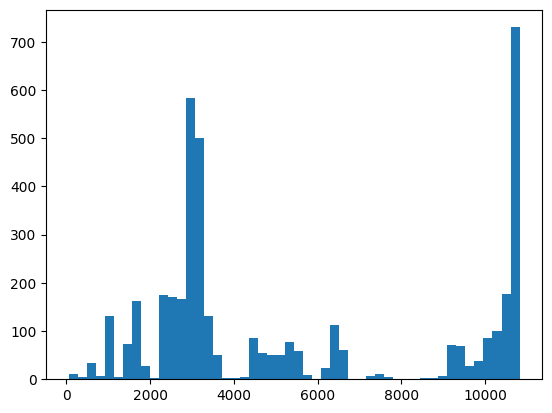

In [309]:
plt.hist(durations[~np.isnan(durations)], bins=50)
plt.show()

In [310]:
print(np.unique(np.round(durations[~np.isnan(durations)], -2)))

[  100.   200.   300.   400.   500.   600.   700.   800.   900.  1000.
  1100.  1200.  1400.  1500.  1600.  1700.  1800.  1900.  2000.  2100.
  2300.  2400.  2500.  2600.  2700.  2800.  2900.  3000.  3100.  3200.
  3300.  3400.  3500.  3600.  3700.  3800.  4100.  4300.  4400.  4500.
  4600.  4700.  4800.  4900.  5000.  5100.  5200.  5300.  5400.  5500.
  5600.  5700.  6200.  6300.  6400.  6500.  6600.  6900.  7100.  7200.
  7300.  7400.  7500.  7600.  8100.  8500.  8600.  8700.  9000.  9100.
  9200.  9300.  9400.  9500.  9600.  9700.  9800.  9900. 10000. 10100.
 10200. 10300. 10400. 10500. 10600. 10700. 10800.]


In [311]:
main_mask = (durations > 3000) & (durations < 3600)
main_capacities = capacities[main_mask]

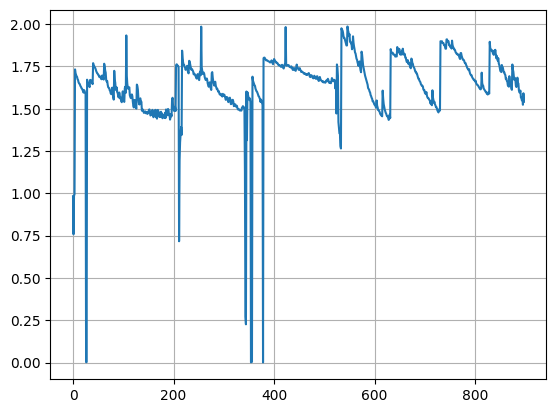

In [312]:
plt.plot(main_capacities)
plt.grid(True)
plt.show()

In [313]:
caps = main_capacities.copy()


jumps = np.where(np.diff(caps) > 0.2)[0]

print(jumps[:10])

[  1   3  27 105 204 211 216 254 344 346]


In [314]:
segments = np.split(caps, jumps + 1)

for i, seg in enumerate(segments):
    print(i, len(seg))

0 2
1 2
2 24
3 78
4 99
5 7
6 5
7 38
8 90
9 2
10 10
11 22
12 44
13 102
14 9
15 98
16 99
17 98
18 69


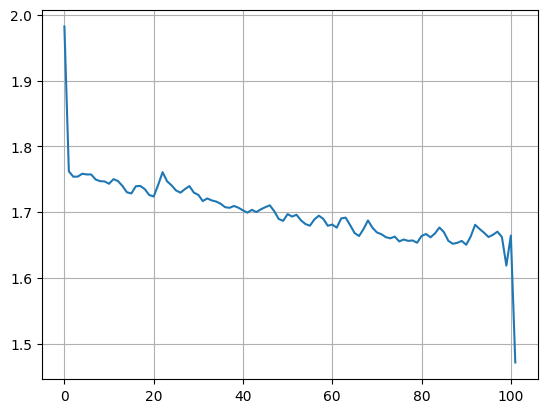

In [315]:
longest_segment = max(segments, key=len)

plt.plot(longest_segment)
plt.grid(True)
plt.show()

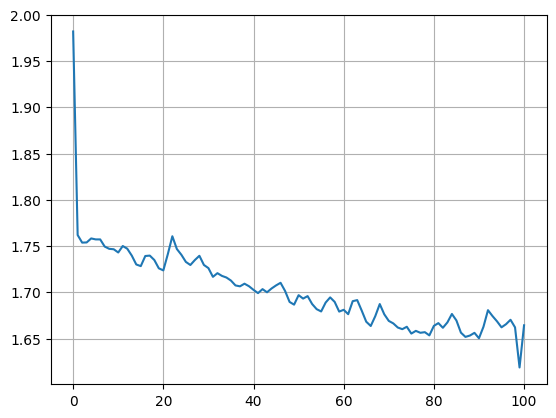

In [316]:
aging = longest_segment[:-1]
plt.plot(aging)
plt.grid(True)
plt.show()

In [317]:
initial_capacity = aging[0]
threshold = 0.8 * initial_capacity

eol_index = np.where(aging <= threshold)[0]

if len(eol_index) > 0:
    eol_cycle = eol_index[0]
    print("EOL cycle:", eol_cycle)
else:
    print("80% threshold not reached in this segment")

80% threshold not reached in this segment


In [318]:
rul = len(aging) - np.arange(len(aging))

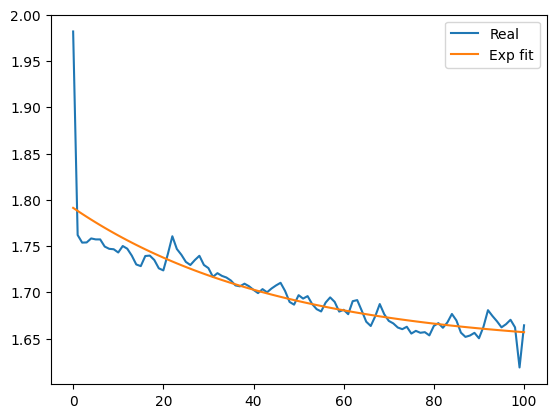

In [319]:
from scipy.optimize import curve_fit
import numpy as np

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

x = np.arange(len(aging))
y = aging

params, _ = curve_fit(exp_decay, x, y, maxfev=10000)

fit = exp_decay(x, *params)

plt.plot(y, label="Real")
plt.plot(fit, label="Exp fit")
plt.legend()
plt.show()

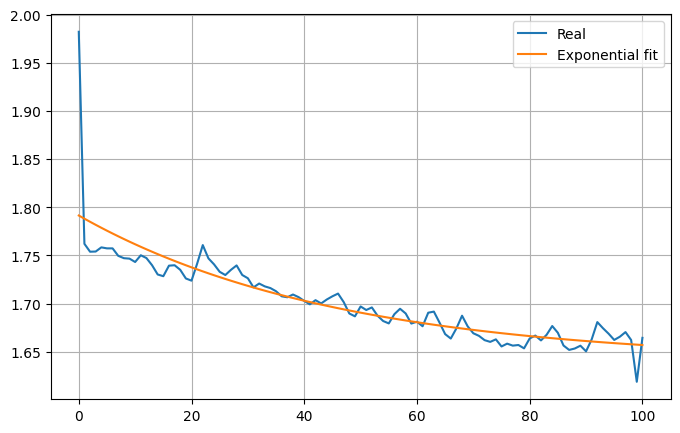

a, b, c: [0.15121379 0.02199031 1.64020363]


In [320]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

x = np.arange(len(aging))
y = aging

params, _ = curve_fit(exp_decay, x, y, maxfev=10000)

a, b, c = params
fit = exp_decay(x, a, b, c)

plt.figure(figsize=(8,5))
plt.plot(y, label="Real")
plt.plot(fit, label="Exponential fit")
plt.legend()
plt.grid(True)
plt.show()

print("a, b, c:", params)

In [321]:
x = np.arange(len(y))
slope, intercept = np.polyfit(x, y, 1)

future_x = np.arange(0, 500)
future_fit = slope * future_x + intercept
print("Initial:", y[0])
print("Threshold (80%):", threshold)
print("Min fitted value in 0–500:", future_fit.min())

Initial: 1.9821591721873992
Threshold (80%): 1.5857273377499195
Min fitted value in 0–500: 1.1384208343264977


In [322]:
future_x = np.arange(0, 3000)
future_fit = exp_decay(future_x, a, b, c)

indices = np.where(future_fit <= threshold)[0]

if len(indices) > 0:
    eol_index = indices[0]
    print("Predicted EOL:", eol_index)
else:
    print("EOL not reached within 3000 cycles")

EOL not reached within 3000 cycles


In [323]:
import numpy as np

if threshold > c:
    k_eol = -1/b * np.log((threshold - c) / a)
    print("Predicted EOL (analytical):", k_eol)
else:
    print("Model never reaches threshold")

Model never reaches threshold


In [324]:
for i, seg in enumerate(segments):
    print(i, len(seg))

0 2
1 2
2 24
3 78
4 99
5 7
6 5
7 38
8 90
9 2
10 10
11 22
12 44
13 102
14 9
15 98
16 99
17 98
18 69


In [325]:
coef = np.polyfit(np.arange(len(aging)), aging, 1)
slope = coef[0]
print("Slope Ah per cycle:", slope)

Slope Ah per cycle: -0.0012542287878330317


In [326]:
initial_capacity = aging[0]
threshold = 0.8 * initial_capacity

delta_needed = threshold - initial_capacity
cycles_to_eol = delta_needed / slope

print("Estimated EOL (linear):", abs(cycles_to_eol))

Estimated EOL (linear): 316.076172292622


In [327]:
x = np.arange(len(aging))
coef = np.polyfit(x, aging, 1)
slope, intercept = coef

initial_capacity = aging[0]
threshold = 0.8 * initial_capacity

# Решаем intercept + slope*k = threshold
k_linear = (threshold - intercept) / slope
k_linear = abs(k_linear)

print("Linear EOL estimate:", k_linear)

Linear EOL estimate: 142.36131672097358


In [328]:
if threshold > c:
    k_exp = -1/b * np.log((threshold - c) / a)
    print("Exponential EOL estimate:", k_exp)
else:
    print("Exponential model never reaches threshold")

Exponential model never reaches threshold


In [329]:
rul = len(aging) - np.arange(len(aging))

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = x.reshape(-1,1)
y_rul = rul

X_train, X_test, y_train, y_test = train_test_split(
    X, y_rul, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(n_estimators=300)
model.fit(X_train, y_train)

pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error
print("ML MAE:", mean_absolute_error(y_test, pred))

ML MAE: 11.533333333333335


In [330]:
future_x = np.arange(0, 400).reshape(-1,1)
future_rul = model.predict(future_x)

eol_ml = np.where(future_rul <= 0)[0]

if len(eol_ml) > 0:
    print("ML EOL estimate:", eol_ml[0])
else:
    print("ML does not reach zero in horizon")

ML does not reach zero in horizon


In [331]:

linear_pred = slope * x + intercept

residual = aging - linear_pred


X = x.reshape(-1,1)
y_res = residual

model = RandomForestRegressor(n_estimators=300)
model.fit(X, y_res)

ml_residual_pred = model.predict(X)

hybrid_pred = linear_pred + ml_residual_pred

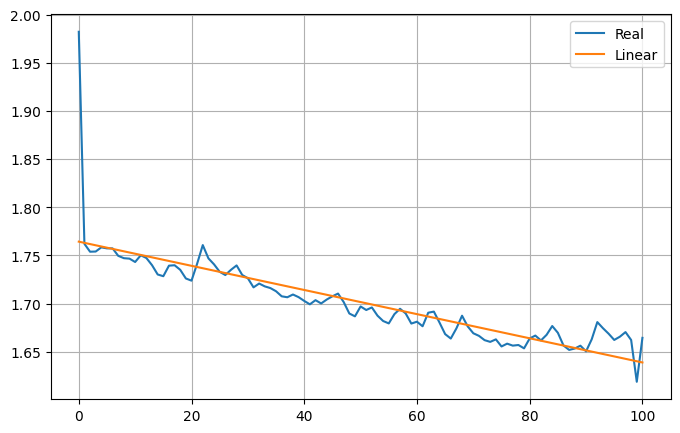

Slope: -0.0012542287878330317


In [332]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

x = np.arange(len(aging))
y = aging

# Линейная регрессия через polyfit
slope, intercept = np.polyfit(x, y, 1)

linear_pred = slope * x + intercept

plt.figure(figsize=(8,5))
plt.plot(y, label="Real")
plt.plot(linear_pred, label="Linear")
plt.legend()
plt.grid(True)
plt.show()

print("Slope:", slope)

In [333]:
initial_capacity = y[0]
threshold = 0.8 * initial_capacity

k_linear = (threshold - intercept) / slope
k_linear = abs(k_linear)

print("Linear EOL estimate:", k_linear)

Linear EOL estimate: 142.36131672097358


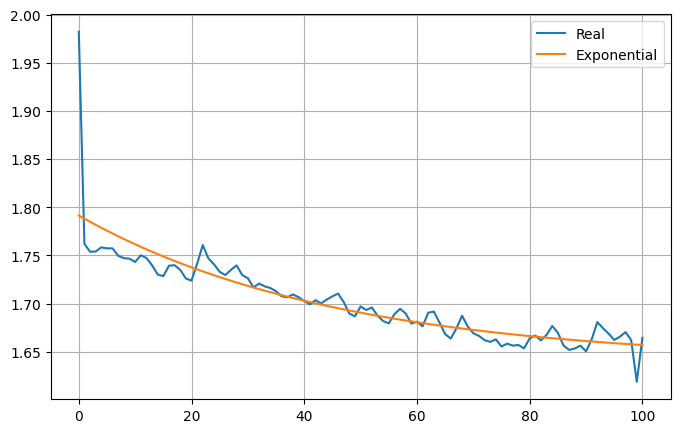

In [334]:
from scipy.optimize import curve_fit

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

params, _ = curve_fit(exp_decay, x, y, maxfev=10000)
a, b, c = params

exp_pred = exp_decay(x, a, b, c)

plt.figure(figsize=(8,5))
plt.plot(y, label="Real")
plt.plot(exp_pred, label="Exponential")
plt.legend()
plt.grid(True)
plt.show()

In [335]:
if threshold > c:
    k_exp = -1/b * np.log((threshold - c) / a)
    print("Exponential EOL estimate:", k_exp)
else:
    print("Exponential model never reaches threshold")

Exponential model never reaches threshold


In [336]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rul = len(y) - x

X = x.reshape(-1,1)
y_rul = rul

X_train, X_test, y_train, y_test = train_test_split(
    X, y_rul, test_size=0.2, shuffle=False
)

rf = RandomForestRegressor(n_estimators=300)
rf.fit(X_train, y_train)

rul_pred = rf.predict(X_test)

print("ML RUL MAE:", mean_absolute_error(y_test, rul_pred))

ML RUL MAE: 11.5


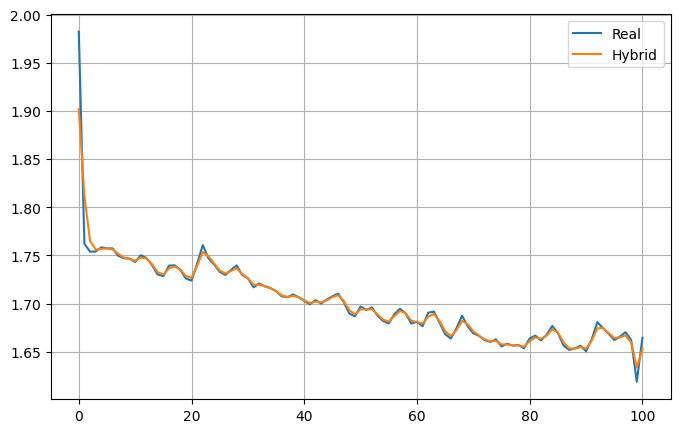

Linear MAE: 0.011030072319712028
Hybrid MAE: 0.0032359347042868305


In [337]:
# Residual
residual = y - linear_pred

rf_res = RandomForestRegressor(n_estimators=300)
rf_res.fit(X, residual)

residual_pred = rf_res.predict(X)

hybrid_pred = linear_pred + residual_pred

plt.figure(figsize=(8,5))
plt.plot(y, label="Real")
plt.plot(hybrid_pred, label="Hybrid")
plt.legend()
plt.grid(True)
plt.show()

print("Linear MAE:", mean_absolute_error(y, linear_pred))
print("Hybrid MAE:", mean_absolute_error(y, hybrid_pred))

In [338]:
n_boot = 200
eol_estimates = []

for _ in range(n_boot):
    idx = np.random.choice(len(x), len(x), replace=True)
    x_sample = x[idx]
    y_sample = y[idx]
    
    slope_b, intercept_b = np.polyfit(x_sample, y_sample, 1)
    
    k_b = (threshold - intercept_b) / slope_b
    eol_estimates.append(abs(k_b))

eol_estimates = np.array(eol_estimates)

print("Mean EOL:", np.mean(eol_estimates))
print("Std EOL:", np.std(eol_estimates))
print("95% CI:", 
      np.percentile(eol_estimates, 2.5),
      np.percentile(eol_estimates, 97.5))

Mean EOL: 144.4012423394703
Std EOL: 8.451961580220459
95% CI: 126.28558634786258 158.15079325061785


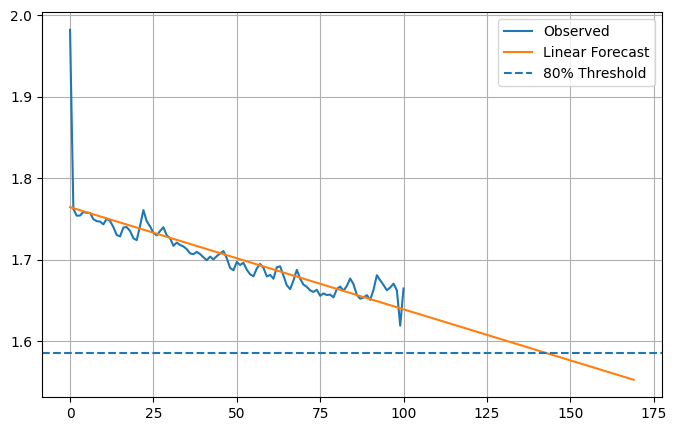

In [339]:
future_x = np.arange(0, int(k_linear*1.2))
future_linear = slope * future_x + intercept

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Observed")
plt.plot(future_x, future_linear, label="Linear Forecast")
plt.axhline(threshold, linestyle="--", label="80% Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [340]:
import pandas as pd

df_feat = pd.DataFrame({
    "cycle": np.arange(len(aging)),
    "capacity": aging
})


df_feat["cap_norm"] = df_feat["capacity"] / df_feat["capacity"].iloc[0]


df_feat["delta_cap"] = df_feat["capacity"].diff()


window = 10
slopes = []

for i in range(len(df_feat)):
    if i < window:
        slopes.append(np.nan)
    else:
        x_local = np.arange(window)
        y_local = df_feat["capacity"].iloc[i-window:i].values
        s, _ = np.polyfit(x_local, y_local, 1)
        slopes.append(s)

df_feat["rolling_slope"] = slopes


df_feat["rolling_std"] = df_feat["capacity"].rolling(window).std()

df_feat = df_feat.dropna().reset_index(drop=True)

In [341]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

rul = len(df_feat) - df_feat["cycle"]

features = ["cap_norm", "delta_cap", "rolling_slope", "rolling_std"]

X = df_feat[features]
y_rul = rul

X_train, X_test, y_train, y_test = train_test_split(
    X, y_rul, test_size=0.2, shuffle=False
)

rf = RandomForestRegressor(n_estimators=500)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Feature-based ML MAE:", mean_absolute_error(y_test, pred))

Feature-based ML MAE: 19.638105263157897


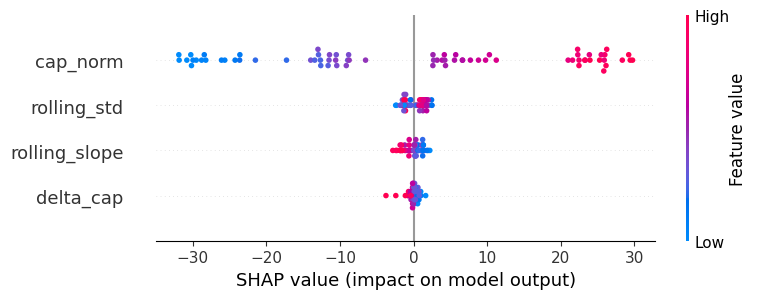

In [342]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

In [343]:

slope, intercept = np.polyfit(df_feat["cycle"], df_feat["capacity"], 1)
linear_pred = slope * df_feat["cycle"] + intercept

residual = df_feat["capacity"] - linear_pred

rf_res = RandomForestRegressor(n_estimators=500)
rf_res.fit(X, residual)

residual_pred = rf_res.predict(X)

hybrid_capacity = linear_pred + residual_pred

print("Hybrid MAE:",
      mean_absolute_error(df_feat["capacity"], hybrid_capacity))

Hybrid MAE: 0.0019915196811331696


In [344]:
noise_levels = [0.001, 0.005, 0.01]
eol_sensitivity = []

for noise in noise_levels:
    noisy = aging + np.random.normal(0, noise, len(aging))
    s, i = np.polyfit(np.arange(len(noisy)), noisy, 1)
    k = (threshold - i) / s
    eol_sensitivity.append(abs(k))

print("EOL under noise:", eol_sensitivity)

EOL under noise: [np.float64(142.59623148324658), np.float64(143.18118908299087), np.float64(144.45160254585997)]


In [345]:
capacities = []
mean_currents = []
mean_temps = []

for f in files:
    try:
        df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
        df.columns = df.columns.str.strip().str.lower()

        if "current_measured" not in df.columns:
            capacities.append(np.nan)
            mean_currents.append(np.nan)
            mean_temps.append(np.nan)
            continue

        discharge = df[df["current_measured"] < 0]

        if len(discharge) < 10:
            capacities.append(np.nan)
            mean_currents.append(np.nan)
            mean_temps.append(np.nan)
            continue

        time = discharge["time"].values
        current = discharge["current_measured"].values
        dt = np.diff(time)
        current_trim = current[:-1]

        cap = -np.sum(current_trim * dt) / 3600

        capacities.append(cap)
        mean_currents.append(discharge["current_measured"].mean())
        mean_temps.append(discharge["temperature_measured"].mean())

    except:
        capacities.append(np.nan)
        mean_currents.append(np.nan)
        mean_temps.append(np.nan)

capacities = np.array(capacities)
mean_temps = np.array(mean_temps)

In [346]:
valid = (~np.isnan(capacities)) & (~np.isnan(mean_temps))

corr = np.corrcoef(capacities[valid], mean_temps[valid])[0,1]
print("Capacity-Temperature correlation:", corr)

Capacity-Temperature correlation: 0.14711292334066645


In [347]:
print(df.columns.tolist())

['voltage_measured', 'current_measured', 'temperature_measured', 'current_charge', 'voltage_charge', 'time']


In [348]:
discharge_files = []

for f in files:
    df = pd.read_csv(os.path.join(battery_path, f), encoding="utf-8-sig")
    df.columns = df.columns.str.strip().str.lower()
    
    if {"current_measured", "voltage_measured", "time"}.issubset(df.columns):
        discharge_files.append(f)

print("Discharge files found:", len(discharge_files))

Discharge files found: 5609


In [349]:
df = pd.read_csv(os.path.join(battery_path, discharge_files[0]), encoding="utf-8-sig")
df.columns = df.columns.str.strip().str.lower()

discharge = df[df["current_measured"] < 0]

In [350]:
df = pd.read_csv(os.path.join(battery_path, files[0]))
df.columns = df.columns.str.strip().str.lower()

discharge = df[df["current_measured"] < 0]

voltage = discharge["voltage_measured"].values
time = discharge["time"].values
current = discharge["current_measured"].values

dt = np.diff(time)
dQ = -current[:-1] * dt / 3600

dV = np.diff(voltage)

dq_dv = dQ / dV

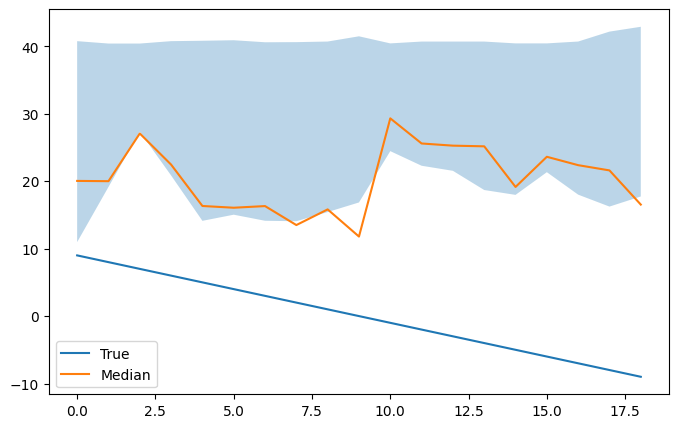

In [351]:
from sklearn.ensemble import GradientBoostingRegressor

quantiles = [0.1, 0.5, 0.9]
models = {}

for q in quantiles:
    gbr = GradientBoostingRegressor(loss="quantile", alpha=q)
    gbr.fit(X_train, y_train)
    models[q] = gbr

pred_10 = models[0.1].predict(X_test)
pred_50 = models[0.5].predict(X_test)
pred_90 = models[0.9].predict(X_test)

plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="True")
plt.plot(pred_50, label="Median")
plt.fill_between(range(len(pred_10)), pred_10, pred_90, alpha=0.3)
plt.legend()
plt.show()

In [352]:
df_feat["temperature"] = mean_temps[valid][:len(df_feat)]

features = [
    "cap_norm",
    "delta_cap",
    "rolling_slope",
    "rolling_std",
    "temperature"
]

X = df_feat[features]

In [353]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(X):
    rf.fit(X.iloc[train_idx], y_rul.iloc[train_idx])
    pred = rf.predict(X.iloc[test_idx])
    print("Fold MAE:",
          mean_absolute_error(y_rul.iloc[test_idx], pred))

Fold MAE: 13.350800000000003
Fold MAE: 10.688
Fold MAE: 12.9716
Fold MAE: 12.629066666666665
Fold MAE: 19.021466666666665


In [360]:
from src.pipeline import run_full_analysis

results = run_full_analysis("../data/raw")

print("Linear EOL:", results["linear_eol"])
print("95% CI:",
      results["eol_ci_low"],
      results["eol_ci_high"])

Linear EOL: 4265.455299715943
95% CI: 2951.3612835292447 6438.953953931124
